In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time

In [18]:
# Load preprocessed data
demand = pd.read_csv('CleanedDemand.csv', index_col=0)
demand = demand.sort_values("pickup_hour")

# Train-test split: 90% train, 10% test — no shuffle
train_df, test_df = train_test_split(
    demand,
    test_size=0.1,
    shuffle=False,
    random_state=42
)

# Long Short-Term Memory
## (Univariate Per-Zone)
- Predicts $\texttt{trip\_count}$ for the next hour per $\texttt{(zone, hour)}$

- Uses $\texttt{[lag\_1, lag\_2, lag\_3, lag\_24, hour\_of\_day, day\_of\_week]}$ as features

- Outputs a single value per row ($\texttt{trip\_count}$)

In [19]:
# Features and target
FEATURE_COLS = ["lag_1", "lag_2", "lag_3", "lag_24", "hour_of_day", "day_of_week"]
TARGET_COL = "trip_count"

# PyTorch Dataset
class TaxiDemandDataset(Dataset):
    def __init__(self, dataframe):
        self.X = dataframe[FEATURE_COLS].values.astype(np.float32)
        self.y = dataframe[TARGET_COL].values.astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.float32)
        )


# Create datasets and loaders
train_dataset = TaxiDemandDataset(train_df)
test_dataset = TaxiDemandDataset(test_df)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


# LSTM model
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch_size, features) -> we add a time dimension for LSTM: (batch_size, seq_len=1, features)
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

# Initialize model, loss, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMRegressor(input_size=len(FEATURE_COLS)).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
def train_model(model, loader, epochs=10):
    model.train()
    epoch_losses = []
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
        avg_loss = total_loss / len(loader.dataset)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    return epoch_losses

# --- Timing: Training ---
start_train = time.time()
lstm_losses = train_model(model, train_loader)
end_train = time.time()
print(f"LSTM Training Time: {end_train - start_train:.2f} seconds")

# --- Timing: Evaluation ---
start_eval = time.time()
model.eval()
y_true, y_pred_lstm = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).cpu().numpy()
        y_true.extend(y_batch.numpy())
        y_pred_lstm.extend(outputs)
        
end_eval = time.time()
print(f"LSTM Evaluation Time: {end_eval - start_eval:.2f} seconds")

# --- Metrics ---
rmse = np.sqrt(mean_squared_error(y_true, y_pred_lstm))
mae = mean_absolute_error(y_true, y_pred_lstm)
print(f"LSTM RMSE: {rmse:.4f}, MAE: {mae:.4f}")

Epoch 1/10, Loss: 0.1013
Epoch 2/10, Loss: 0.0490
Epoch 3/10, Loss: 0.0462
Epoch 4/10, Loss: 0.0450
Epoch 5/10, Loss: 0.0438
Epoch 6/10, Loss: 0.0428
Epoch 7/10, Loss: 0.0421
Epoch 8/10, Loss: 0.0414
Epoch 9/10, Loss: 0.0406
Epoch 10/10, Loss: 0.0403
LSTM Training Time: 44.59 seconds
LSTM Evaluation Time: 0.37 seconds
LSTM RMSE: 0.2492, MAE: 0.1055


# Transformer Model Code
- Treating each feature as a "token"

- Using a single layer encoder with positional embeddings (learnable or fixed)

- Outputting a single regression value: $\texttt{trip\_count}$

In [20]:
# Dataset reuse from earlier
class TaxiDemandDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.X = df[FEATURE_COLS].values.astype(np.float32)
        self.y = df[TARGET_COL].values.astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.float32)
        )

train_loader = DataLoader(TaxiDemandDataset(train_df), batch_size=128, shuffle=True)
test_loader = DataLoader(TaxiDemandDataset(test_df), batch_size=128)

# Transformer Model
class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output = nn.Linear(d_model, 1)

    def forward(self, x):
        # Add sequence dimension: (batch_size, seq_len=1, input_dim)
        x = x.unsqueeze(1)
        x = self.embedding(x)
        x = self.transformer(x)
        x = self.output(x).squeeze(1).squeeze(1)
        return x

# Set up training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerRegressor(input_dim=len(FEATURE_COLS)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

def train_transformer(model, loader, epochs=10):
    model.train()
    epoch_losses = []
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
        avg_loss = total_loss / len(loader.dataset)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    return epoch_losses

# --- Training Timer ---
start_train = time.time()
transformer_losses = train_transformer(model, train_loader)
end_train = time.time()
print(f"Transformer Training Time: {end_train - start_train:.2f} seconds")

# --- Evaluation Timer ---
start_eval = time.time()
model.eval()
y_true, y_pred_transformer = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).detach().cpu().numpy()
        y_true.extend(y_batch.numpy())
        y_pred_transformer.extend(preds)
end_eval = time.time()
print(f"Transformer Evaluation Time: {end_eval - start_eval:.2f} seconds")

# --- Compute Metrics ---
rmse = np.sqrt(mean_squared_error(y_true, y_pred_transformer))
mae = mean_absolute_error(y_true, y_pred_transformer)
print(f"Transformer RMSE: {rmse:.4f}, MAE: {mae:.4f}")

Epoch 1, Loss: 0.0721
Epoch 2, Loss: 0.0507
Epoch 3, Loss: 0.0473
Epoch 4, Loss: 0.0458
Epoch 5, Loss: 0.0448
Epoch 6, Loss: 0.0429
Epoch 7, Loss: 0.0418
Epoch 8, Loss: 0.0415
Epoch 9, Loss: 0.0409
Epoch 10, Loss: 0.0403
Transformer Training Time: 163.57 seconds
Transformer Evaluation Time: 0.49 seconds
Transformer RMSE: 0.2645, MAE: 0.1548


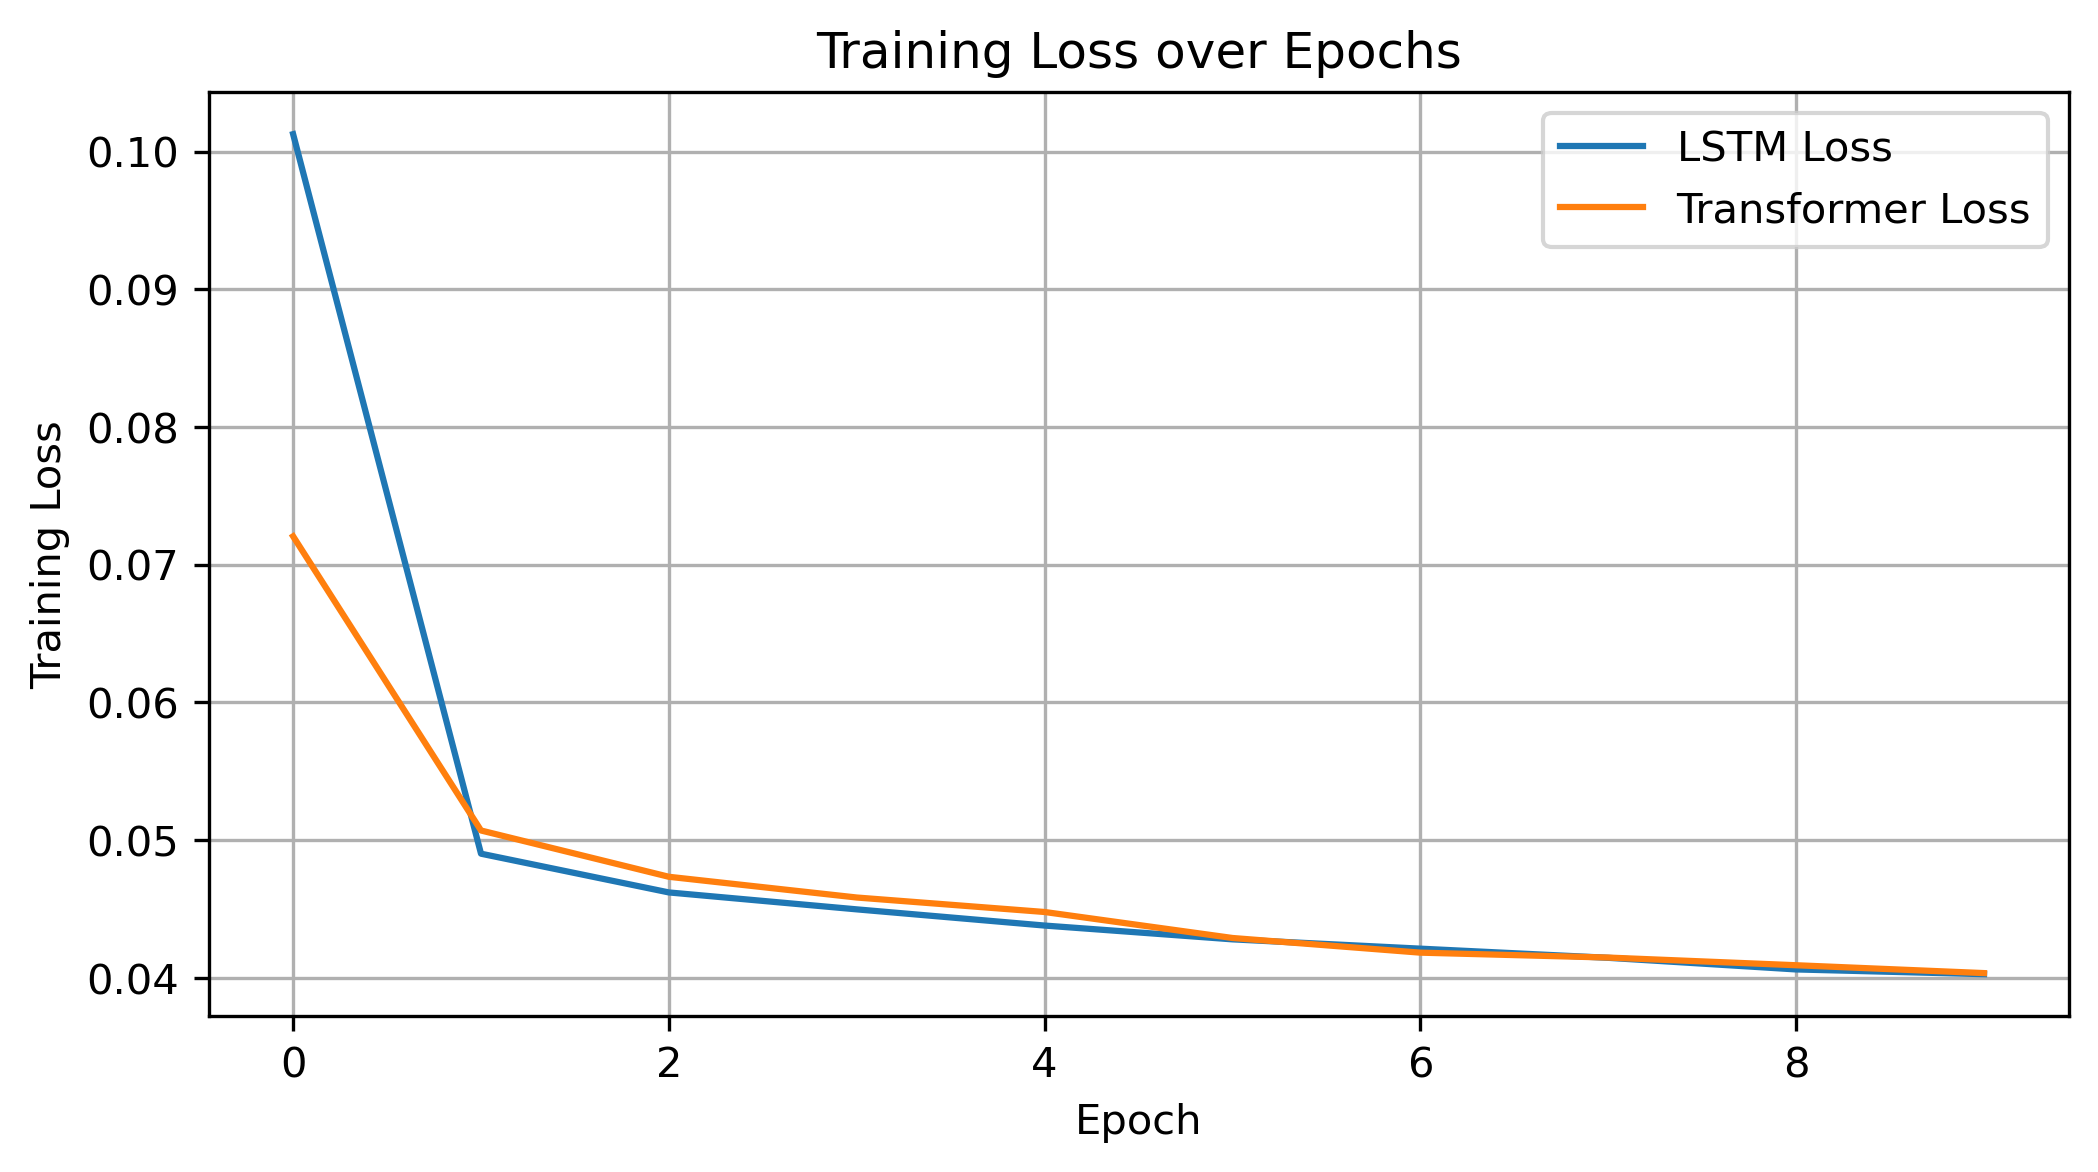

In [21]:
plt.figure(figsize=(8, 4), dpi=300)
plt.plot(lstm_losses, label="LSTM Loss")
plt.plot(transformer_losses, label="Transformer Loss")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title("Training Loss over Epochs")
plt.legend()
plt.grid(True)
plt.show()

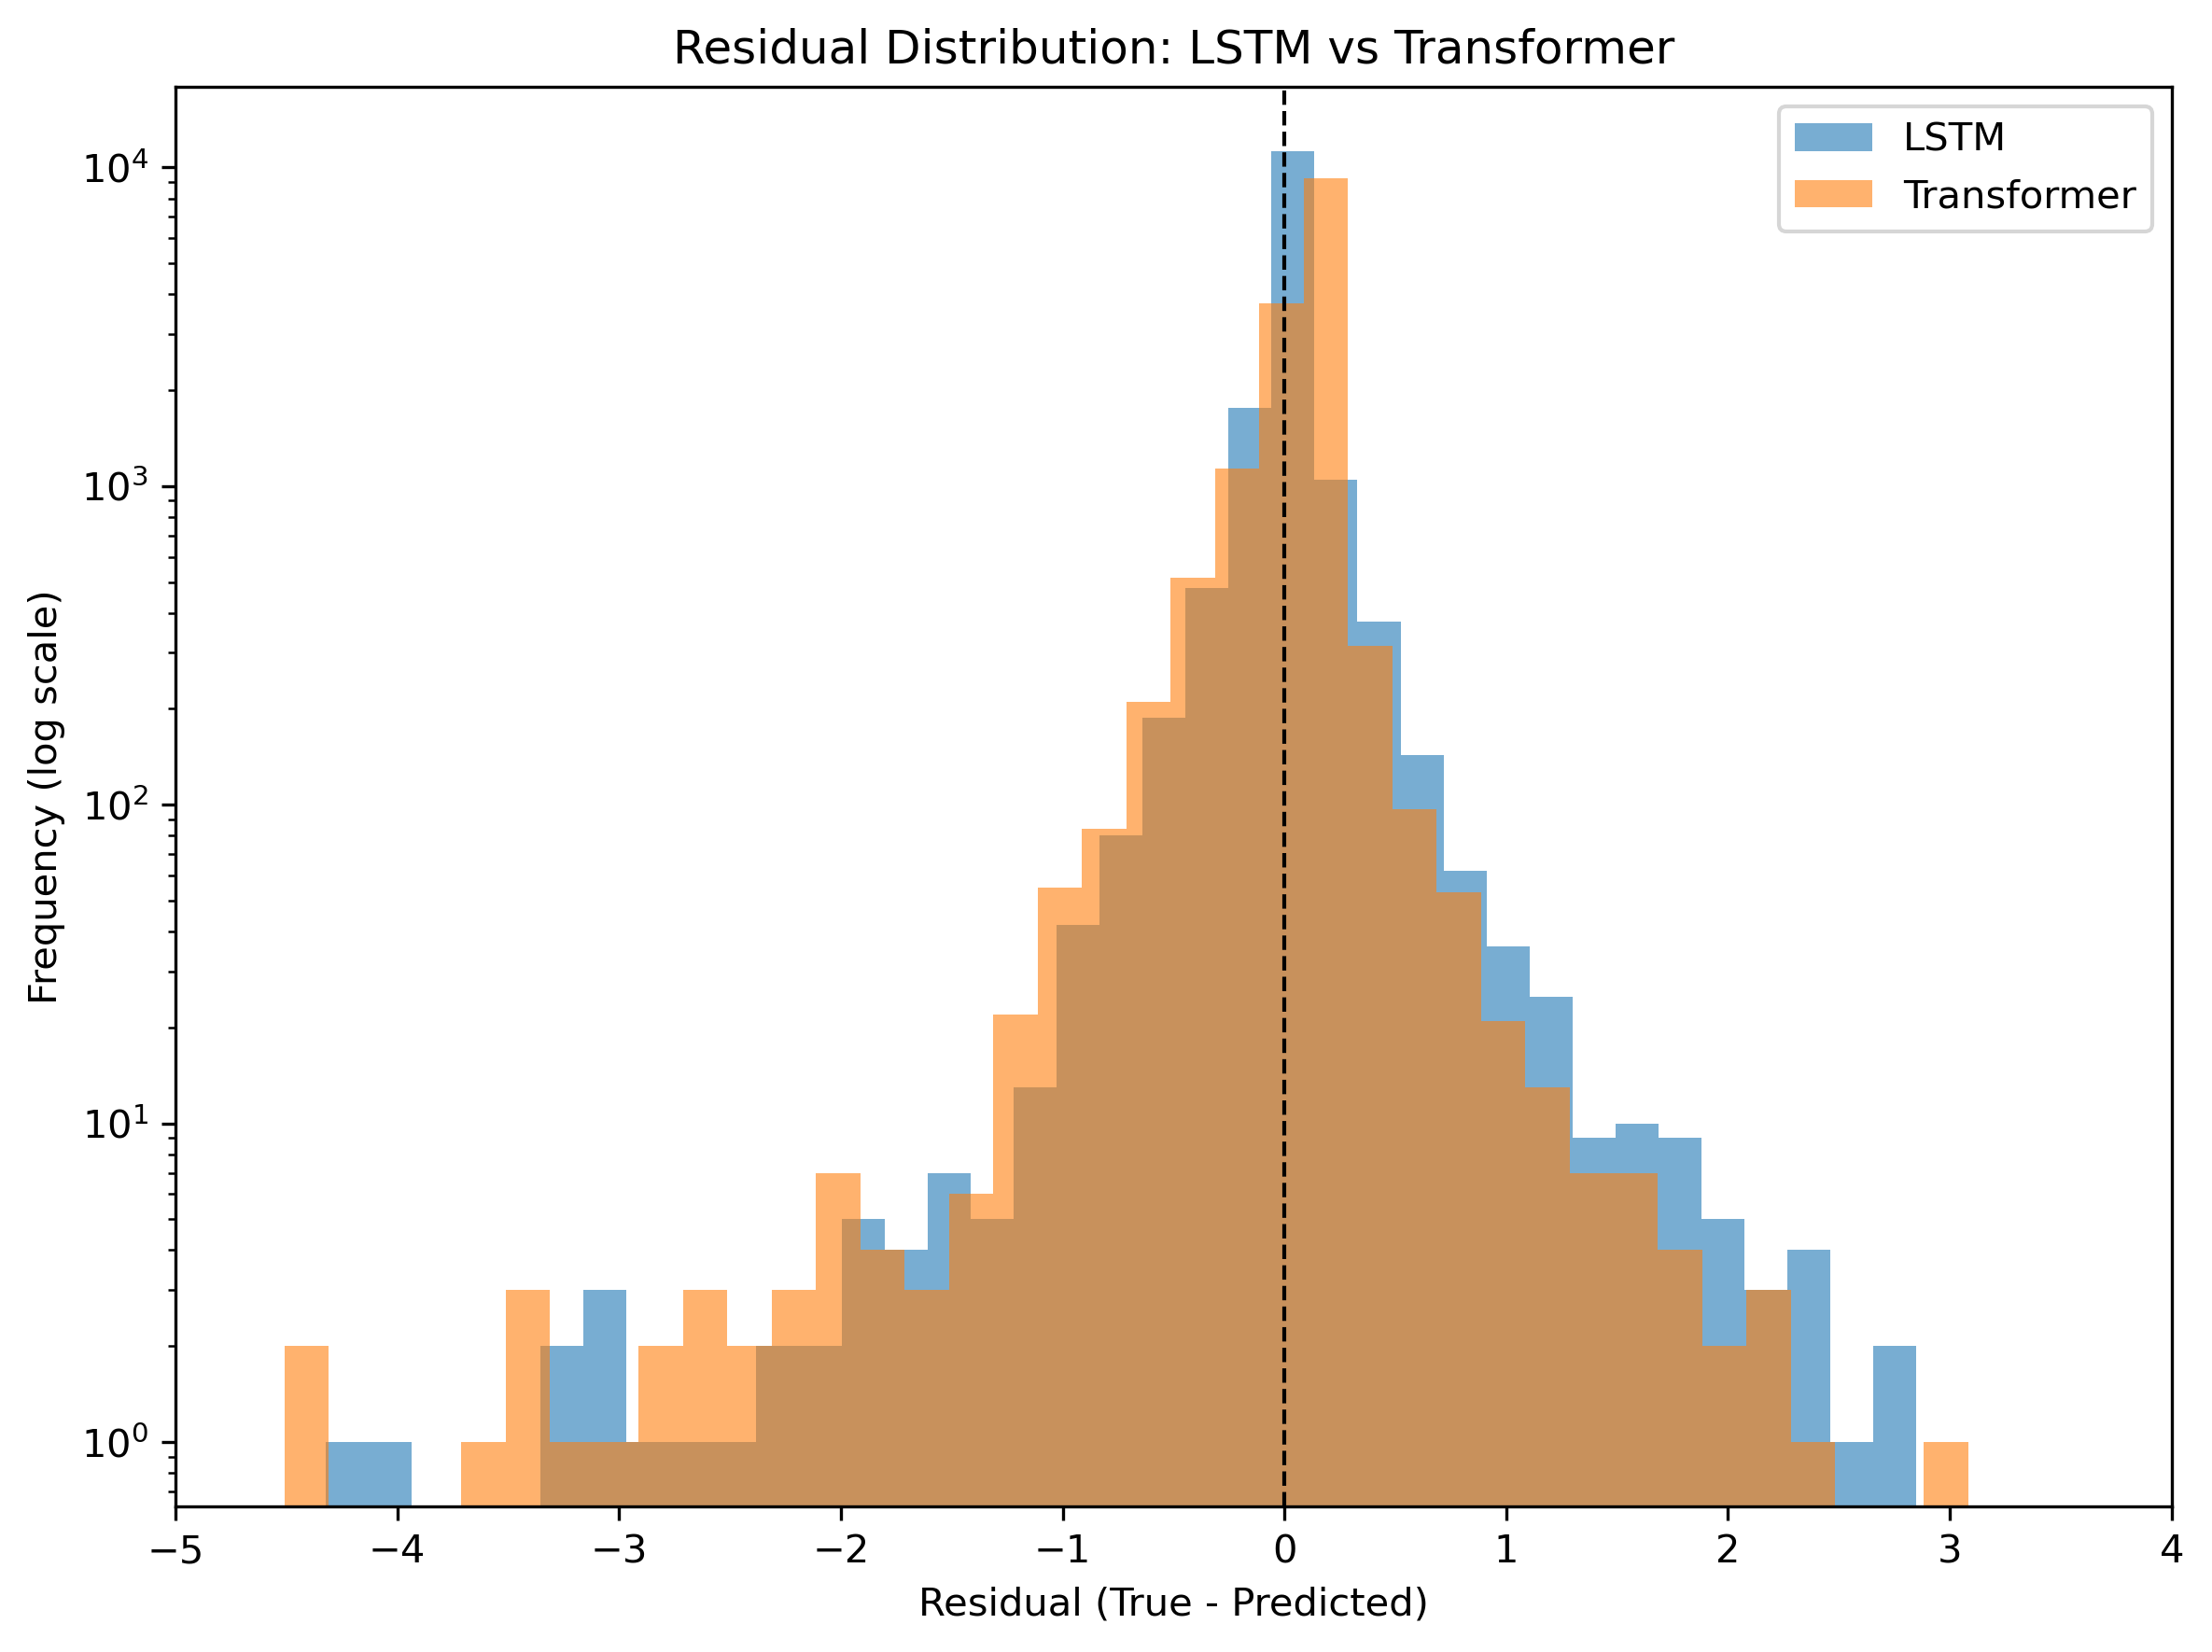

In [34]:
# Compute residuals
lstm_residuals = np.array(y_true) - np.array(y_pred_lstm)
trans_residuals = np.array(y_true) - np.array(y_pred_transformer)

# Plot
plt.figure(figsize=(8, 6), dpi=300)
plt.hist(lstm_residuals, bins=50, alpha=0.6, label='LSTM')
plt.hist(trans_residuals, bins=50, alpha=0.6, label='Transformer')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Frequency (log scale)")
plt.title("Residual Distribution: LSTM vs Transformer")
plt.xlim((-5,4))
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

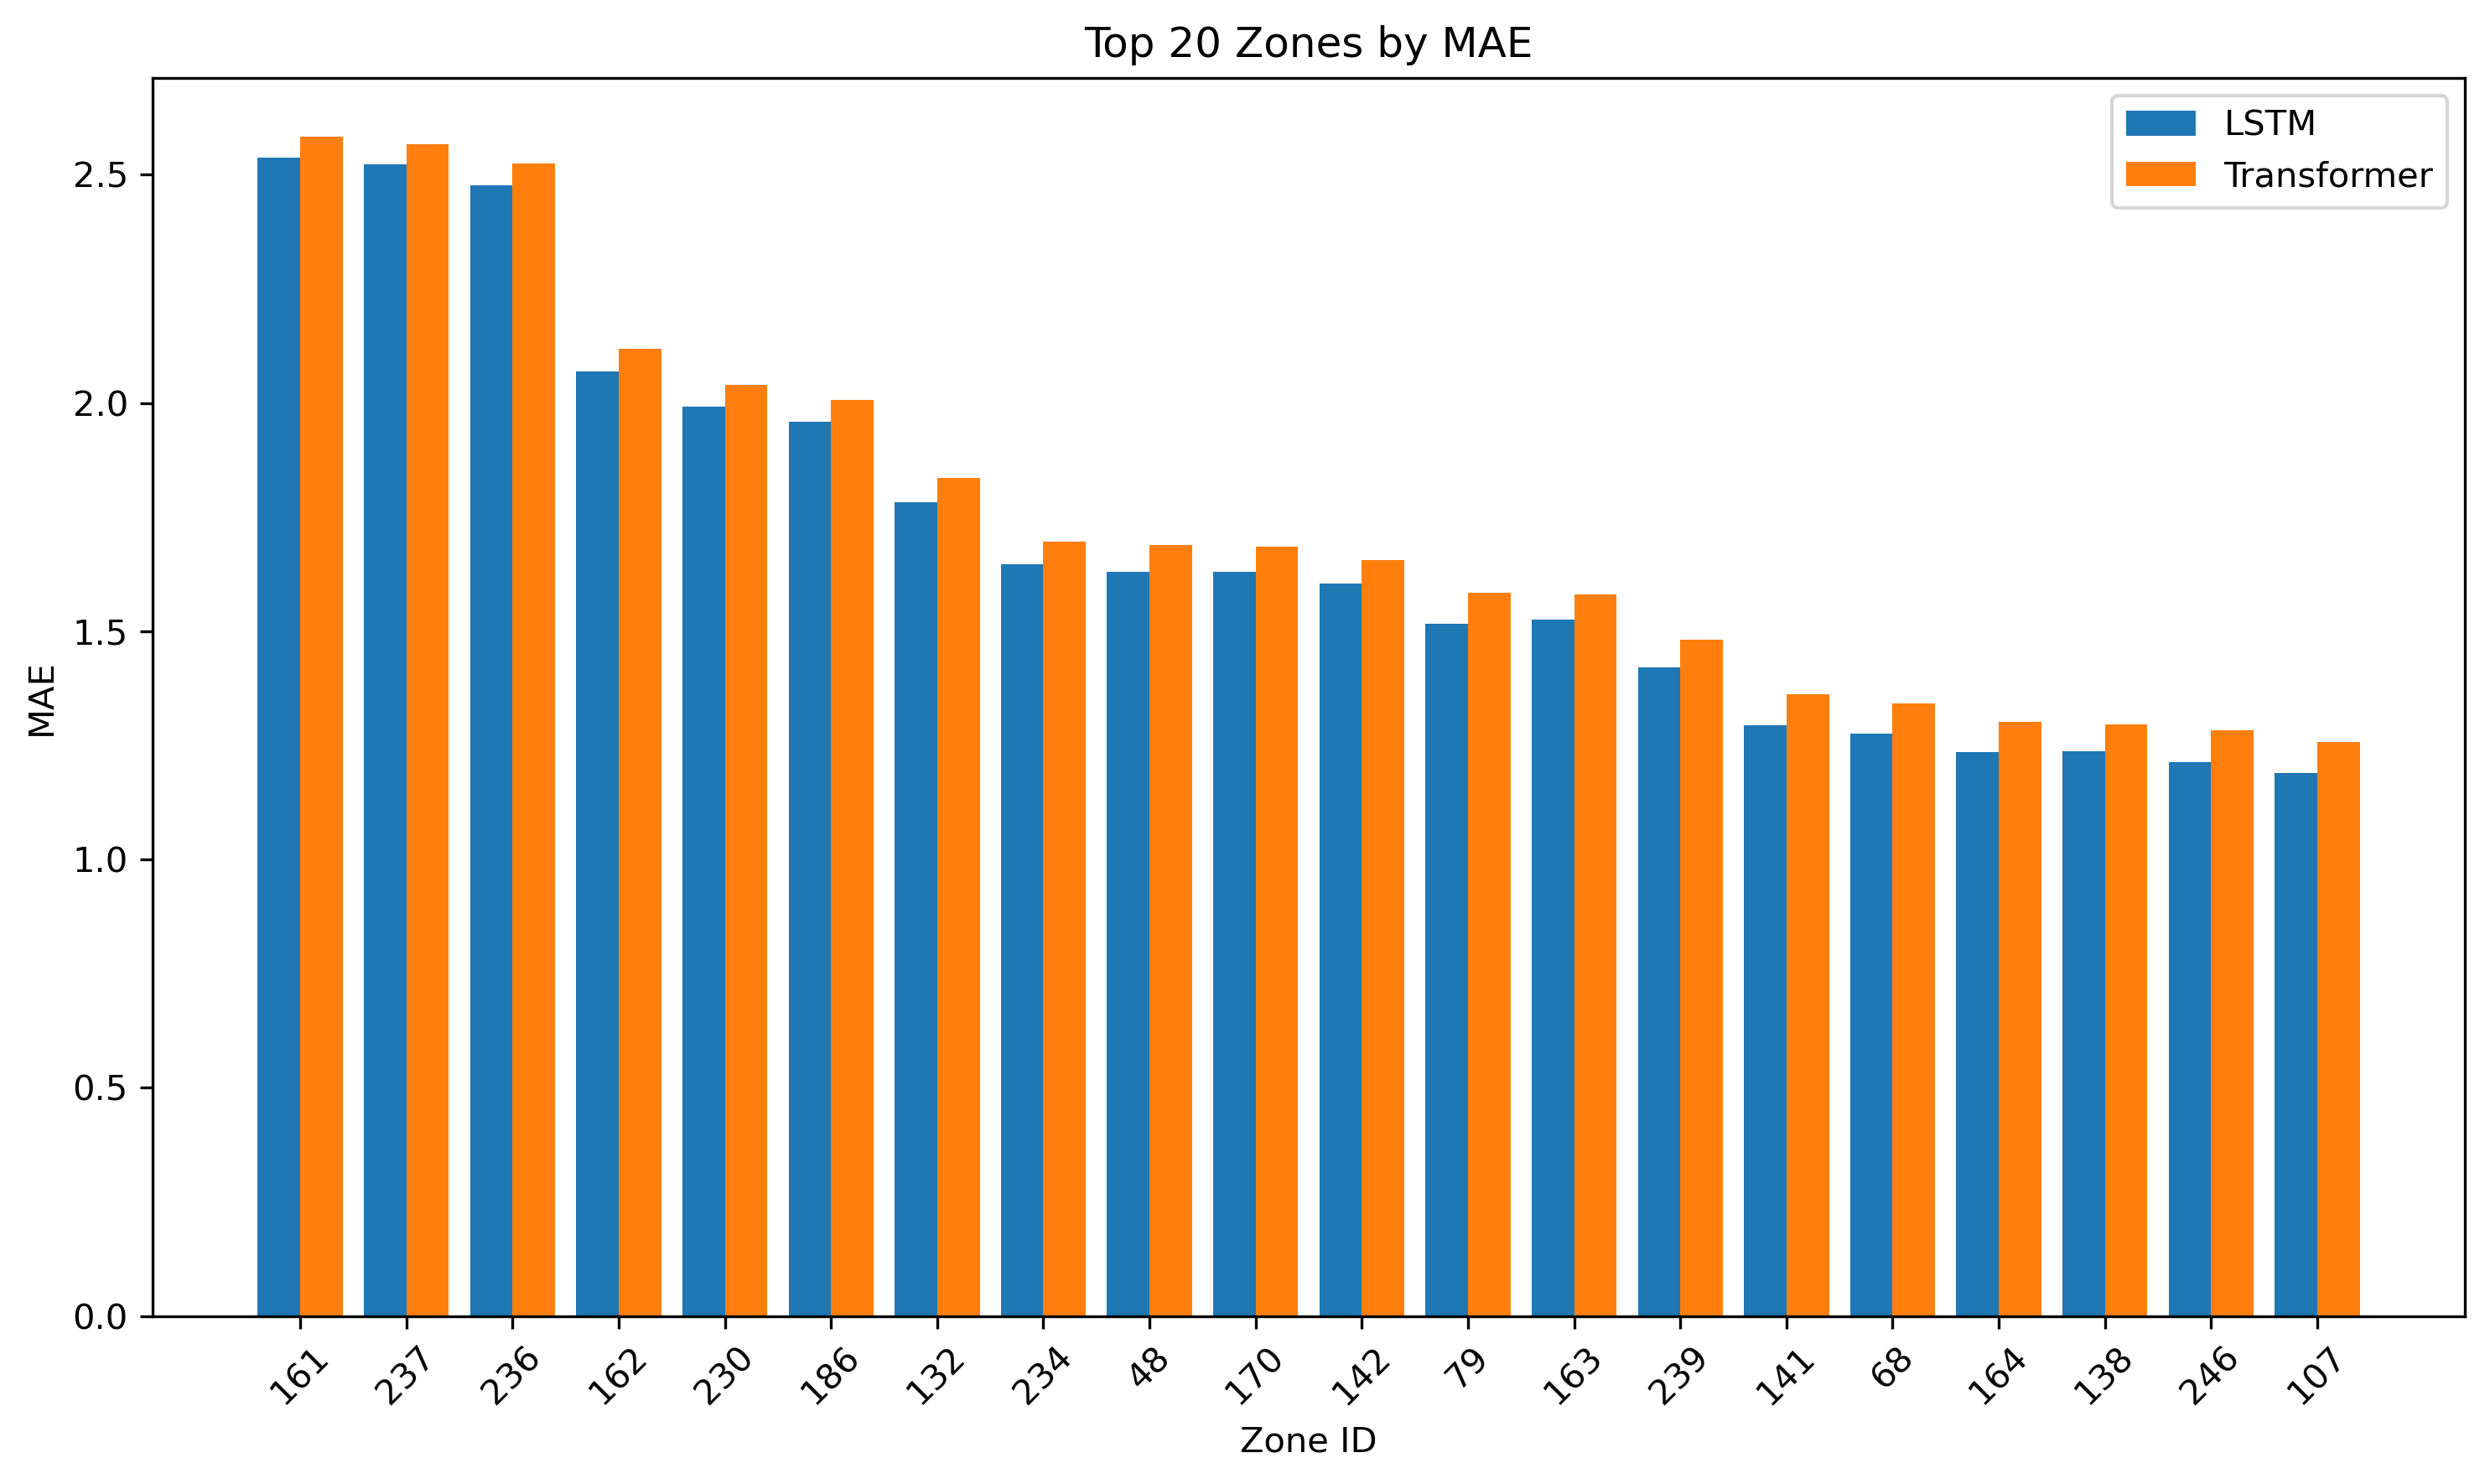

In [33]:
# Create DataFrame for zone-wise error
zone_eval_df = test_df.copy()
zone_eval_df["true"] = y_true
zone_eval_df["pred_lstm"] = y_pred_lstm
zone_eval_df["pred_transformer"] = y_pred_transformer

# Compute MAE per zone
mae_by_zone = (
    zone_eval_df.groupby("PULocationID")
    .agg(mae_lstm=("true", lambda x: np.mean(np.abs(x - zone_eval_df.loc[x.index, "pred_lstm"]))),
         mae_trans=("true", lambda x: np.mean(np.abs(x - zone_eval_df.loc[x.index, "pred_transformer"]))))
    .reset_index()
)

# Plot top 20
top_n = 20
top_zones = mae_by_zone.sort_values("mae_trans", ascending=False).head(top_n)

plt.figure(figsize=(10, 6), dpi=300)
bar_width = 0.4
x = np.arange(top_n)

plt.bar(x - bar_width/2, top_zones["mae_lstm"], width=bar_width, label='LSTM')
plt.bar(x + bar_width/2, top_zones["mae_trans"], width=bar_width, label='Transformer')

plt.xticks(x, top_zones["PULocationID"], rotation=45)
plt.xlabel("Zone ID")
plt.ylabel("MAE")
plt.title("Top 20 Zones by MAE")
plt.legend()
plt.tight_layout()
plt.show()
